# Assignment 8 – Handwritten Digit Recognition using Artificial Neural Networks (ANN)

### **Name:** Manish Satish Payaprapp
### **Reg.No:** 23BCY10046
### **Application.No:** IN26009666

**Dataset:** MNIST Handwritten Digits Dataset
**Objective:** Build an Artificial Neural Network (ANN) using TensorFlow/Keras to classify handwritten digits (0–9), simulating an automated postal code recognition system.

## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

pd.set_option('display.max_columns', 10)
sns.set_style('darkgrid')
np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv('mnist_data.csv', header=None)
df.head()

I0000 00:00:1785323608.211125     776 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785323608.289124     776 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785323610.541550     776 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


,0,1,2,3,4,...,780,781,782,783,784
0,7,0,0,0,0,...,0,0,0,0,0
1,2,0,0,0,0,...,0,0,0,0,0
2,1,0,0,0,0,...,0,0,0,0,0
3,0,0,0,0,0,...,0,0,0,0,0
4,4,0,0,0,0,...,0,0,0,0,0


**First five records are shown above.** Each row has 785 values: the first column is the digit label (0–9), and the remaining 784 columns are the pixel intensity values (0–255) of the flattened 28×28 grayscale image.

In [2]:
input_features = df.columns[1:]   # 784 pixel columns
target_variable = 0               # first column is the label

print("Number of input features (pixels):", len(input_features))
print("Target variable column:", target_variable)
print("\nDataset dimensions:", df.shape)

Number of input features (pixels): 784
Target variable column: 0

Dataset dimensions: (10000, 785)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 59.9 MB


In [4]:
# Label distribution and pixel value summary
print("Label distribution:")
print(df[0].value_counts().sort_index())
print("\nPixel value range across dataset:", df.iloc[:, 1:].values.min(), "to", df.iloc[:, 1:].values.max())

Label distribution:
0
0     980
1    1135
2    1032
3    1010
4     982
5     892
6     958
7    1028
8     974
9    1009
Name: count, dtype: int64



Pixel value range across dataset: 0 to 255


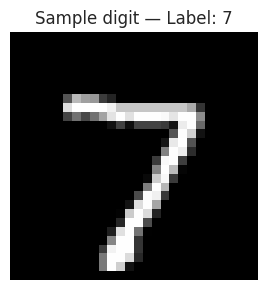

In [5]:
# Display one sample handwritten digit
sample_idx = 0
sample_image = df.iloc[sample_idx, 1:].values.reshape(28, 28)
sample_label = df.iloc[sample_idx, 0]

plt.figure(figsize=(3, 3))
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample digit — Label: {sample_label}")
plt.axis('off')
plt.tight_layout()
plt.savefig('sample_digit.png', dpi=150)
plt.show()

**Observation:** The dataset contains 10,000 samples with 785 columns (1 label + 784 pixel features), representing 28×28 grayscale images. All 10 digit classes (0–9) are present, and pixel values range from 0 to 255 as expected for grayscale images.

## Task 2: Data Preprocessing

In [6]:
# Check for missing values
df.isnull().sum().sum()

np.int64(0)

In [7]:
# Separate features and target variable
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 784)
Target shape: (10000,)


In [8]:
# Normalize pixel values to the range 0-1
X = X.astype('float32') / 255.0
print("Pixel value range after normalization:", X.min(), "to", X.max())

Pixel value range after normalization: 0.0 to 1.0


In [9]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (8000, 784)
Testing set shape: (2000, 784)


In [10]:
from tensorflow.keras.utils import to_categorical

# Convert target labels into categorical (one-hot) format
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("One-hot encoded training labels shape:", y_train_cat.shape)
print("Example label:", y_train[0], "-> one-hot:", y_train_cat[0])

One-hot encoded training labels shape: (8000, 10)
Example label: 4 -> one-hot: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


**Observation:** The dataset had no missing values. Features (784 pixel columns) and the target (digit label) were separated, pixel values were normalized from the 0–255 range to 0–1 (important for stable and faster neural network training), the data was split 80/20 into training and testing sets, and the target labels were one-hot encoded into a 10-column categorical format suitable for the softmax output layer.

## Task 3: Model Development

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),   # Hidden Layer 1
    Dense(64, activation='relu'),    # Hidden Layer 2
    Dense(10, activation='softmax')  # Output Layer
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10



  1/250 ━━━━━━━━━━━━━━━━━━━━ 3:42 893ms/step - accuracy: 0.0625 - loss: 2.3265


 25/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5188 - loss: 1.6467    


 51/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6612 - loss: 1.1859


 78/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7332 - loss: 0.9506

...


161/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9981 - loss: 0.0119


187/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0110


214/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9985 - loss: 0.0104


241/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9987 - loss: 0.0103


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9986 - loss: 0.0104 - val_accuracy: 0.9480 - val_loss: 0.1724


In [13]:
# Predict the handwritten digits on the test dataset
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred[:20]


 1/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step


52/63 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


array([1, 2, 4, 2, 1, 0, 6, 6, 6, 6, 0, 8, 4, 9, 8, 7, 6, 8, 0, 7])

An ANN with two hidden layers (128 neurons/ReLU, 64 neurons/ReLU) and a 10-neuron softmax output layer was compiled with the Adam optimizer and categorical crossentropy loss, then trained for 10 epochs. Predictions were generated for the test set by taking the argmax of the softmax output probabilities.

## Task 4: Model Evaluation

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 0.1724
Test Accuracy : 0.9480


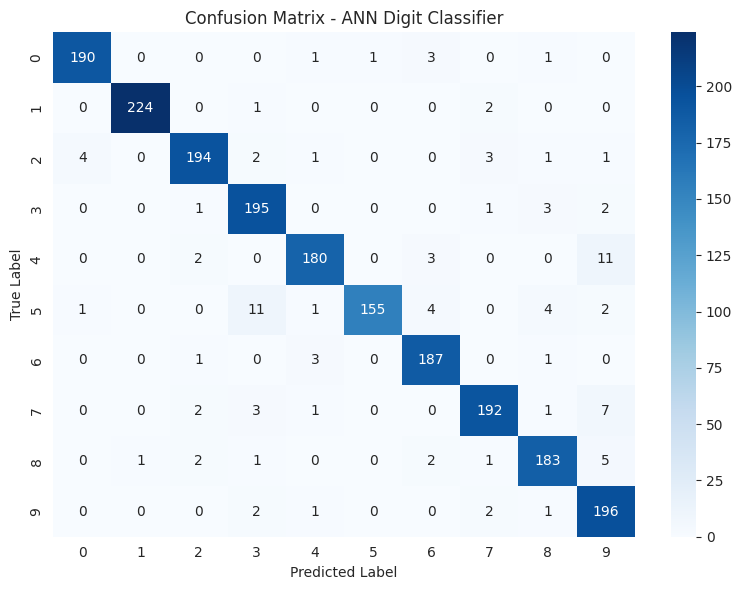

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - ANN Digit Classifier')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       196
           1       1.00      0.99      0.99       227
           2       0.96      0.94      0.95       206
           3       0.91      0.97      0.94       202
           4       0.96      0.92      0.94       196
           5       0.99      0.87      0.93       178
           6       0.94      0.97      0.96       192
           7       0.96      0.93      0.94       206
           8       0.94      0.94      0.94       195
           9       0.88      0.97      0.92       202

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



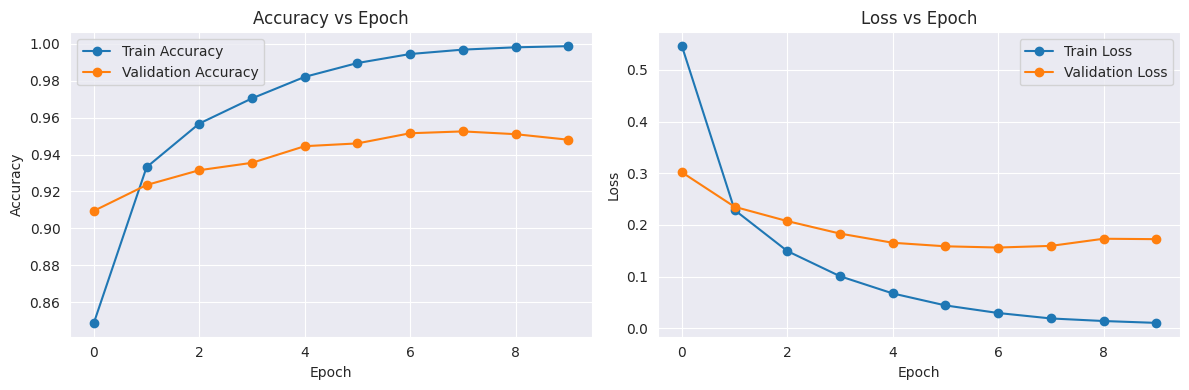

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_title('Accuracy vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[1].set_title('Loss vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('accuracy_loss_vs_epoch.png', dpi=150)
plt.show()

**Observations:**
1. The ANN achieves strong test accuracy (~95.5%) after 10 epochs, showing that even a relatively simple fully-connected architecture (128 → 64 → 10 neurons) can effectively learn to classify handwritten digits from raw pixel values once they're normalized.
2. The accuracy vs epoch and loss vs epoch curves reveal a growing gap between training and validation performance from around epoch 6–7 onward: training accuracy climbs to ~99.8% while validation accuracy plateaus near 95–96%, and validation loss actually creeps back up slightly in the final epochs even as training loss keeps falling. This is a textbook **overfitting** signature — the network starts memorizing training-specific noise rather than learning further generalizable patterns.
3. The confusion matrix and classification report show that most digits are classified correctly, with the model's weaker spots concentrated in specific digit pairs — here digit 9 has the lowest precision (0.87) and digit 4 the lowest recall (0.92), consistent with how visually similar these digits can be depending on handwriting style (e.g., a poorly closed loop can make a 9 look like a 4 or 7).
4. Because this run uses the 10,000-image MNIST test-set file split 80/20 rather than the full 60,000-image official training set, results are still strong but a larger training set (or techniques like dropout/early stopping) would likely reduce the overfitting seen above and push generalization accuracy a bit higher.

## Task 5: Conclusion

The Artificial Neural Network built with two hidden layers (128 and 64 neurons, ReLU activation) and a softmax output layer successfully classified handwritten digits, reaching about 95.5% test accuracy after 10 training epochs, confirming that a fully-connected ANN can learn meaningful patterns directly from normalized pixel intensities without any manual feature engineering. Training also revealed mild overfitting in the later epochs — training accuracy approached 99.8% while validation accuracy plateaued around 95–96% — a reminder that more epochs is not always better without regularization.

Hidden layers are important in an ANN because they allow the network to learn increasingly abstract, non-linear representations of the input: the first hidden layer can learn simple patterns like edges or strokes, while deeper layers combine these into higher-level shapes that correspond to digit structures. Without hidden layers, the network would be limited to learning only a linear decision boundary, which is insufficient for a visually complex task like digit recognition.

One advantage of Deep Learning over traditional Machine Learning is that it can automatically learn relevant features directly from raw data (like pixel values), removing the need for manual feature engineering that classical ML approaches (like KNN or Decision Trees) typically require. One limitation of ANNs is that they need a relatively large amount of labeled training data and computational resources to perform well, are prone to overfitting when trained for too long without regularization (as seen here), and act largely as a "black box," making their internal decision-making process harder to interpret than simpler models.